<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/part2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 — Exploratory Data Analysis

This notebook builds the foundation for all Part 2 experiments. We explore the
Warehouse Object Detection Dataset, decide on filtering thresholds based on the
actual data distribution, and produce a clean sample index that every training
notebook will load directly. We already took an investigation locally, I am just repeating the highlights and going deeper to take decisions into how to handle the dataset for the models

1. **Setup** — mount Drive, imports, paths
2. **Why not COCO** — evidence that the COCO/YOLO formats have corrupted labels, while was trickier but ocrrrect
3. **Raw format inspection** — understand the .npy structure and label JSON quirks
4. **Parsing** — build a clean sample index from raw annotations

In [1]:
 # mount drive
from google.colab import drive
drive.mount('/content/drive')

# standard library
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Mounted at /content/drive


In [2]:
# all paths in one place
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')

# raw is the source of truth
RAW_ROOT = DRIVE_ROOT / 'raw'
RAW_DIRS = {
    split: {
        'images': RAW_ROOT / split / 'images',
        'anns':   RAW_ROOT / split / 'annotations',
    }
    for split in ['train', 'val', 'test']
}

# coco is kept only for the comparison section (section 2)
COCO_ROOT = DRIVE_ROOT / 'coco'
COCO_ANNS = COCO_ROOT / 'annotations' / 'instances_train.json'
COCO_IMGS = COCO_ROOT / 'images' / 'train'

# output location for the sample index
INDEX_DIR = DRIVE_ROOT / 'sample_index'
INDEX_DIR.mkdir(parents=True, exist_ok=True)

# check everything exists
for split, d in RAW_DIRS.items():
    n_imgs = len(list(d['images'].glob('*.png'))) if d['images'].exists() else 0
    n_anns = len(list(d['anns'].glob('*_bbox.npy'))) if d['anns'].exists() else 0
    print(f'raw/{split}: {n_imgs} images, {n_anns} bbox files')

print(f'\ncoco train annotations exist: {COCO_ANNS.exists()}')
print(f'index output dir: {INDEX_DIR}')

raw/train: 4654 images, 4654 bbox files
raw/val: 1125 images, 1125 bbox files
raw/test: 1124 images, 1124 bbox files

coco train annotations exist: True
index output dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/sample_index


## 2. Why not COCO?

The dataset ships in three parallel formats (`raw/`, `coco/`, `yolo/`) that should
contain the same annotations in different encodings. We compare them on a single
image to verify that assumption.

COCO and YOLO are internally consistent but assign bounding boxes to
the wrong class labels. The raw Omniverse output is the only reliable source.
The cells below reproduce the evidence.

In [3]:
# pick one image that exists in the train split
SAMPLE = 'warehouse_000001.png'
STEM = SAMPLE[:-4]

img_path   = RAW_DIRS['train']['images'] / SAMPLE
raw_bbox   = RAW_DIRS['train']['anns'] / f'{STEM}_bbox.npy'
raw_labels = RAW_DIRS['train']['anns'] / f'{STEM}_labels.json'

img = Image.open(img_path)
W, H = img.size
print(f'image: {SAMPLE}, size: {W}x{H}')

# --- RAW annotations ---
arr = np.load(raw_bbox, allow_pickle=True)
with open(raw_labels) as f:
    raw_label_map = json.load(f)

def parse_raw_class(label_str):
    # omniverse tags look like "data,wall" or "ceiling,data" - drop the 'data' meta tag
    parts = [p.strip() for p in label_str.split(',')]
    real = [p for p in parts if p and p != 'data']
    return real[0] if real else None

raw_boxes = []
for entry in arr:
    sid = int(entry['semanticId'])
    info = raw_label_map.get(str(sid))
    if info is None:
        continue
    name = parse_raw_class(info['class'] if isinstance(info, dict) else info)
    if name is None:
        continue
    occl = float(entry['occlusionRatio'])
    # drop degenerate and heavily occluded boxes just for this visualization
    if occl < 0 or occl >= 0.95:
        continue
    x1, y1, x2, y2 = int(entry['x_min']), int(entry['y_min']), int(entry['x_max']), int(entry['y_max'])
    if x1 == 0 and y1 == 0 and x2 >= W - 1 and y2 >= H - 1:
        continue
    if (x2 - x1) < 3 or (y2 - y1) < 3:
        continue
    raw_boxes.append({'box': (x1, y1, x2, y2), 'name': name})

# --- COCO annotations ---
with open(COCO_ANNS) as f:
    coco = json.load(f)
cat_map = {c['id']: c['name'] for c in coco['categories']}
img_id = next(im['id'] for im in coco['images'] if im['file_name'] == SAMPLE)
coco_boxes = []
for ann in coco['annotations']:
    if ann['image_id'] != img_id:
        continue
    x, y, w, h = ann['bbox']
    coco_boxes.append({
        'box': (int(x), int(y), int(x + w), int(y + h)),
        'name': cat_map[ann['category_id']],
    })

print(f'RAW (filtered for visibility): {len(raw_boxes)} boxes')
print(f'COCO: {len(coco_boxes)} boxes')

image: warehouse_000001.png, size: 512x512
RAW (filtered for visibility): 544 boxes
COCO: 18 boxes


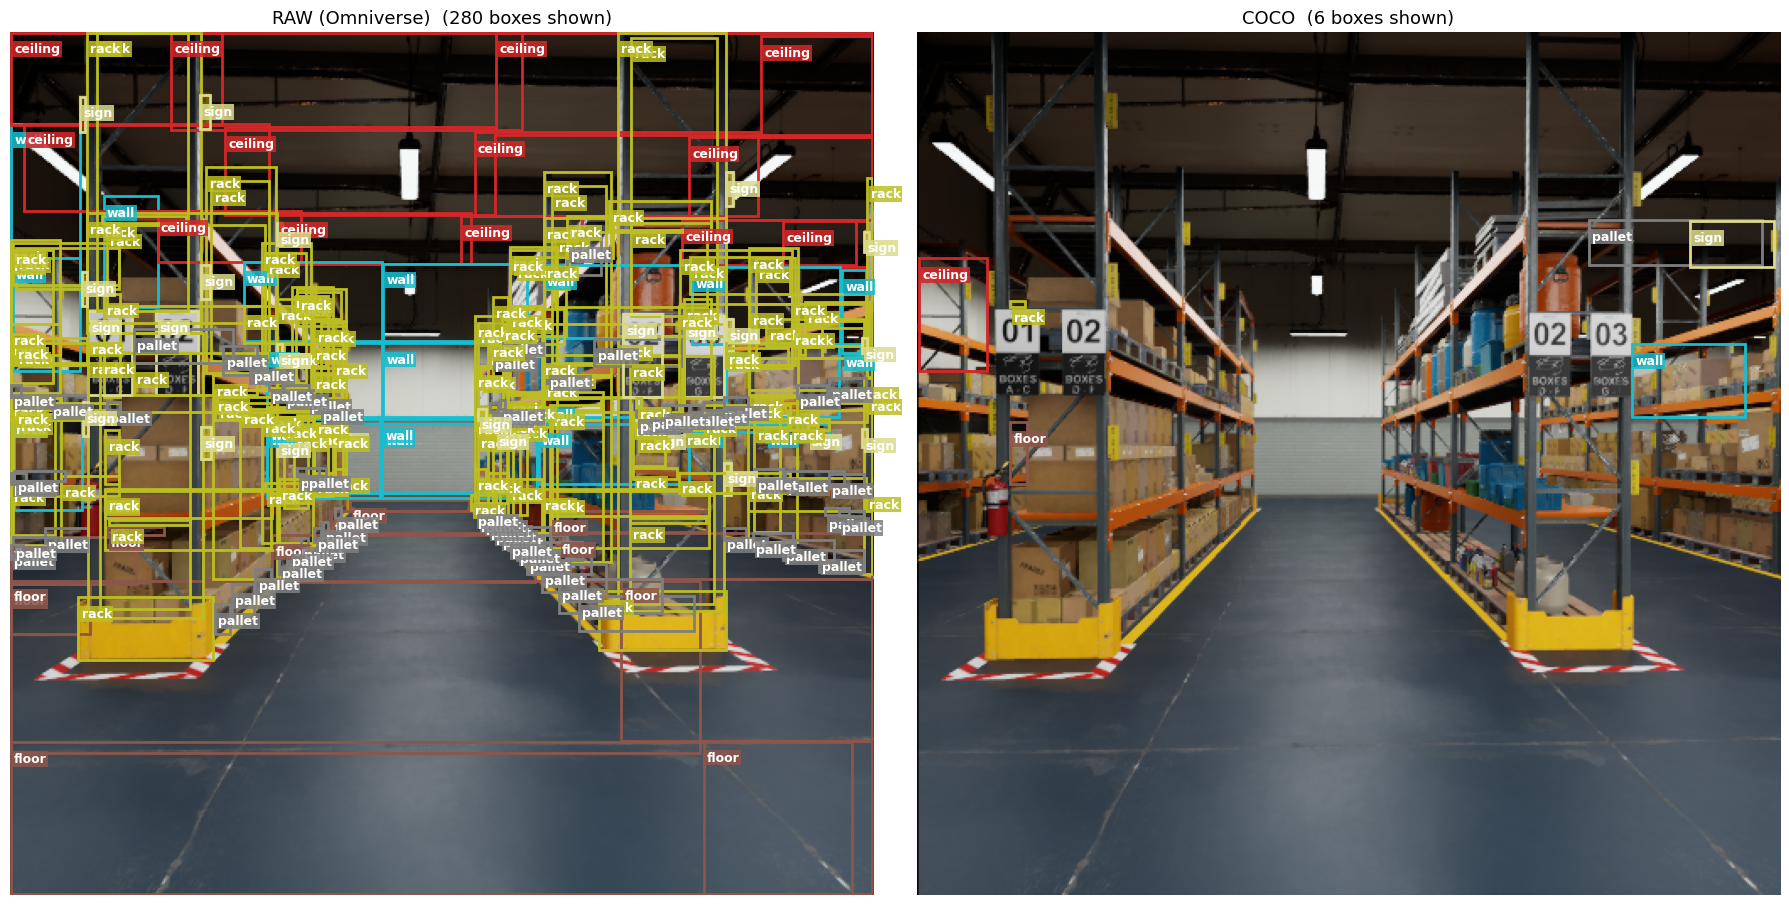

In [4]:
# show only these classes otherwise the raw panel has 600+ boxes and is unreadable
CLASSES_TO_SHOW = ['floor', 'wall', 'pallet', 'sign', 'ceiling', 'rack']

# same color per class across both panels so we can compare
import matplotlib.cm as cm
all_names = sorted(set(r['name'] for r in raw_boxes) | set(r['name'] for r in coco_boxes))
cmap = plt.colormaps['tab20'].resampled(max(len(all_names), 1))
class_colors = {n: cmap(i) for i, n in enumerate(all_names)}

def draw_panel(ax, boxes, title, filter_set):
    ax.imshow(img)
    shown = 0
    for r in boxes:
        if r['name'] not in filter_set:
            continue
        x1, y1, x2, y2 = r['box']
        color = class_colors[r['name']]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 + 2, max(8, y1 + 12), r['name'], color='white', fontsize=9,
                fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.85, edgecolor='none', pad=1))
        shown += 1
    ax.set_title(f'{title}  ({shown} boxes shown)', fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
draw_panel(axes[0], raw_boxes,  'RAW (Omniverse)', CLASSES_TO_SHOW)
draw_panel(axes[1], coco_boxes, 'COCO',            CLASSES_TO_SHOW)
plt.tight_layout()
plt.show()